# Neural Quantum Embedding: Pushing the Limits of Quantum Supervised Learning (nn_embedding)

This implementation is based on prior work by [Hur *et al.*](https://arxiv.org/abs/2311.11412).

This notebook will demonstrate the usage of a Neural Quantum Embedding as presented in the paper.

## 0. Setup and imports

In [1]:
import sys
import warnings
from pathlib import Path

import merlin as ml
import torch.nn as nn

REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT))

warnings.filterwarnings("ignore")

from papers.nn_embedding.lib.merlin_based_model import (  # noqa: E402
    NeuralEmbeddingMerLinModel
)
from papers.nn_embedding.utils.data import (  # noqa: E402
    data_load_and_process
)
from papers.nn_embedding.utils.plotting import (  # noqa: E402
    plot_trace_distance,quick_loss_plot,plot_accuracies
)

## 1. Loading the Dataset To Classify (MNIST)

For the purpose of this tutorial, just like in the paper, we will classify the MNIST dataset restricted to the 0 and 1 digits. We will also apply PCA to this dataset to only have 8 features per image. We will use 300 samples per class.

In [2]:
x_train, x_test, y_train, y_test = data_load_and_process(
            dataset="mnist",
            feature_reduction=8,
            classes=[0, 1],
            samples_per_class=300,
        )
y_test

tensor([0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
        0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
        1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
        0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
        1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
        0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
        1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
        0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
        1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,

## 2. Create the models

In the nn_embedding pipeline, three models are needed.
1. An untrainable quantum embedder that takes for input the output of the classical model and prepares a state.
2. A trainable classical model that assigns parameters to the quantum embedder for a classical input.
3. A trainable quantum model that takes the encoded state and classifies the data.

Lets define these models.

### 2.1 Quantum embedder
This layer will receive its parameter values from the classical model. It encodes the features into quantum states via the classical model.


In this repository, for the MerLin based method, a universal unitary was given as the quantum embedder.

For MerLin models, the quantum embedder must be a MerLin ``QuantumLayer`` with ``input_size=0``. The modifiable parameters will be the trainable ones that will be changed by the classical model. The embedder must not have amplitude encoding on and must return amplitudes.

In [3]:
circ = ml.CircuitBuilder(n_modes=8)
circ.add_entangling_layer()
embedder = ml.QuantumLayer(
    input_size=0,
    builder=circ,
    n_photons=4,
    measurement_strategy=ml.MeasurementStrategy.AMPLITUDES,
)
embedder

QuantumLayer(
  (_photon_loss_transform): PhotonLossTransform()
  (_detector_transform): DetectorTransform()
  (measurement_mapping): Amplitudes()
)

### 2.2 Classical model
This model will be trained to give the quantum embedder its optimal parameters for the classical input x.

Lets create a simple model with three linear layers. We need to match the last layer with the number of parameters in the quantum embedder.

In [4]:
classical_model = nn.Sequential(
    nn.Linear(8, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10,sum([i.numel() for i in embedder.parameters()])),
    )
classical_model

Sequential(
  (0): Linear(in_features=8, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=56, bias=True)
)

### 2.3 Quantum classifier

This layer takes the encoded states and does the classification of the dataset.

We will once again use a universal unitary to train.

This model must be a ``QuantumLayer`` with amplitude encoding on and the probabilities measurement strategy.

In [5]:
circ = ml.CircuitBuilder(n_modes=8)
circ.add_entangling_layer()
classifier = ml.QuantumLayer(
    builder=circ,
    n_photons=4,
    amplitude_encoding=True,
    measurement_strategy=ml.MeasurementStrategy.PROBABILITIES,
)
classifier

QuantumLayer(
  (_photon_loss_transform): PhotonLossTransform()
  (_detector_transform): DetectorTransform()
  (measurement_mapping): Probabilities()
)

## 3. Create the main module

With those models created, we can combine them into the main module that executes the nn_embedding pipeline.

In [6]:
model=NeuralEmbeddingMerLinModel(classical_model=classical_model,quantum_embedding_layer=embedder,quantum_classifier=classifier,num_classes=2)
model

NeuralEmbeddingMerLinModel(
  (classical_encoder): Sequential(
    (0): Linear(in_features=8, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=56, bias=True)
  )
  (quantum_embedding_layer): QuantumLayer(
    (_photon_loss_transform): PhotonLossTransform()
    (_detector_transform): DetectorTransform()
    (measurement_mapping): Amplitudes()
  )
  (quantum_classifier): QuantumLayer(
    (_photon_loss_transform): PhotonLossTransform()
    (_detector_transform): DetectorTransform()
    (measurement_mapping): Probabilities()
  )
  (output_grouper): LexGrouping()
  (similarity_layer): _SimilarityLayer(
    (fidelity_layer): QuantumLayer(
      (_photon_loss_transform): PhotonLossTransform()
      (_detector_transform): DetectorTransform()
      (measurement_mapping): Probabilities()
    )
  )
  (embedding_training_model): _TrainingModule()
  (model): _TrainedEmbeddingModel(
 

## 4. Train the embedding

The first part of the NQE pipeline is to train the embedding. To do so, you just need to call the ``train_embedding`` method of the object. 

We will use the Adam optimiser with a 0.01 learning rate, the default optimizing procedure. We will also return the data which returns:
- The loss per epoch
- The trace distance between the average encoded state of each class for the train dataset.
- The trace distance between the average encoded state of each class for the test dataset.
- The loss lower bound generated by the encoded states of the training dataset.
- The loss lower bound generated by the encoded states of the test dataset.

In [7]:
losses_embedding,train_distances,test_distances,loss_lb_train,loss_lb_test=model.train_embedding(x_train=x_train,y_train=y_train,x_test=x_test,y_test=y_test,num_epochs=50,batch_size=150,return_data=True)
train_distances

Epoch 1 had a loss of 0.4416828453540802
Epoch 2 had a loss of 0.390857994556427
Epoch 3 had a loss of 0.3884666860103607
Epoch 4 had a loss of 0.28700536489486694
Epoch 5 had a loss of 0.24372565746307373
Epoch 6 had a loss of 0.1811673790216446
Epoch 7 had a loss of 0.12644872069358826
Epoch 8 had a loss of 0.09891556203365326
Epoch 9 had a loss of 0.07766833901405334
Epoch 10 had a loss of 0.0867651179432869
Epoch 11 had a loss of 0.0554957389831543
Epoch 12 had a loss of 0.04730817675590515
Epoch 13 had a loss of 0.05040502920746803
Epoch 14 had a loss of 0.04477526992559433
Epoch 15 had a loss of 0.03405756130814552
Epoch 16 had a loss of 0.027140477672219276
Epoch 17 had a loss of 0.037694141268730164
Epoch 18 had a loss of 0.04017558693885803
Epoch 19 had a loss of 0.04074986279010773
Epoch 20 had a loss of 0.0309336856007576
Epoch 21 had a loss of 0.021078528836369514
Epoch 22 had a loss of 0.04064815863966942
Epoch 23 had a loss of 0.04140010476112366
Epoch 24 had a loss of 0.

[tensor(0.2484),
 tensor(0.3307),
 tensor(0.4248),
 tensor(0.5226),
 tensor(0.6157),
 tensor(0.7027),
 tensor(0.7797),
 tensor(0.8397),
 tensor(0.8823),
 tensor(0.9081),
 tensor(0.9241),
 tensor(0.9325),
 tensor(0.9363),
 tensor(0.9343),
 tensor(0.9300),
 tensor(0.9231),
 tensor(0.9171),
 tensor(0.9114),
 tensor(0.9065),
 tensor(0.9035),
 tensor(0.9045),
 tensor(0.9086),
 tensor(0.9164),
 tensor(0.9254),
 tensor(0.9357),
 tensor(0.9435),
 tensor(0.9504),
 tensor(0.9567),
 tensor(0.9609),
 tensor(0.9629),
 tensor(0.9644),
 tensor(0.9659),
 tensor(0.9674),
 tensor(0.9688),
 tensor(0.9699),
 tensor(0.9706),
 tensor(0.9715),
 tensor(0.9726),
 tensor(0.9738),
 tensor(0.9747),
 tensor(0.9756),
 tensor(0.9763),
 tensor(0.9768),
 tensor(0.9772),
 tensor(0.9775),
 tensor(0.9775),
 tensor(0.9776),
 tensor(0.9776),
 tensor(0.9775),
 tensor(0.9774)]

### 5. Train the classifier
The second step of the nn_embedding pipeline is to train the quantum classifier. To do so, you just need to call the ``train_classifier`` method of the object. 

We will use the Adam optimiser with a 0.01 learning rate, the default optimizing procedure. We will also return the data which returns:
- The loss per epoch
- The training accuracy per epoch
- The test accuracy per epoch

In [8]:
losses_classifier, train_accs, test_accs=model.train_classifier(x_train=x_train,y_train=y_train,x_test=x_test,y_test=y_test,batch_size=150,num_epochs=50,return_data=True)
test_accs

Epoch 1 had a loss of 0.5375056862831116
Epoch 2 had a loss of 0.5156368017196655
Epoch 3 had a loss of 0.5049517750740051
Epoch 4 had a loss of 0.486937016248703
Epoch 5 had a loss of 0.4807802736759186
Epoch 6 had a loss of 0.47028741240501404
Epoch 7 had a loss of 0.4555568993091583
Epoch 8 had a loss of 0.4455704689025879
Epoch 9 had a loss of 0.4213404953479767
Epoch 10 had a loss of 0.4204605519771576
Epoch 11 had a loss of 0.41078123450279236
Epoch 12 had a loss of 0.3885246813297272
Epoch 13 had a loss of 0.37565353512763977
Epoch 14 had a loss of 0.3763737380504608
Epoch 15 had a loss of 0.35390350222587585
Epoch 16 had a loss of 0.3487565517425537
Epoch 17 had a loss of 0.3409189283847809
Epoch 18 had a loss of 0.3226906955242157
Epoch 19 had a loss of 0.33411839604377747
Epoch 20 had a loss of 0.3156631290912628
Epoch 21 had a loss of 0.2979927659034729
Epoch 22 had a loss of 0.3003526031970978
Epoch 23 had a loss of 0.2885584533214569
Epoch 24 had a loss of 0.29112765192985

[42.833333333333336,
 50.166666666666664,
 51.333333333333336,
 54.333333333333336,
 60.0,
 67.0,
 76.16666666666667,
 80.83333333333333,
 84.66666666666667,
 85.83333333333333,
 88.16666666666667,
 89.5,
 90.16666666666667,
 90.33333333333333,
 90.83333333333333,
 91.16666666666667,
 91.33333333333333,
 91.33333333333333,
 91.5,
 91.66666666666667,
 91.83333333333333,
 91.83333333333333,
 92.66666666666667,
 93.83333333333333,
 94.16666666666667,
 94.66666666666667,
 94.83333333333333,
 95.33333333333333,
 95.83333333333333,
 96.5,
 96.66666666666667,
 97.0,
 97.83333333333333,
 98.33333333333333,
 98.5,
 98.5,
 98.5,
 98.5,
 98.5,
 98.66666666666667,
 98.83333333333333,
 99.0,
 99.16666666666667,
 99.16666666666667,
 99.16666666666667,
 99.16666666666667,
 99.33333333333333,
 99.33333333333333,
 99.33333333333333,
 99.33333333333333]

## 6. Plot the results
We will take the results and plot the training distance per embedding training epoch, the loss per classifier training epoch and the accuracies per classifier training epoch.

### 6.1. Trace distance plot

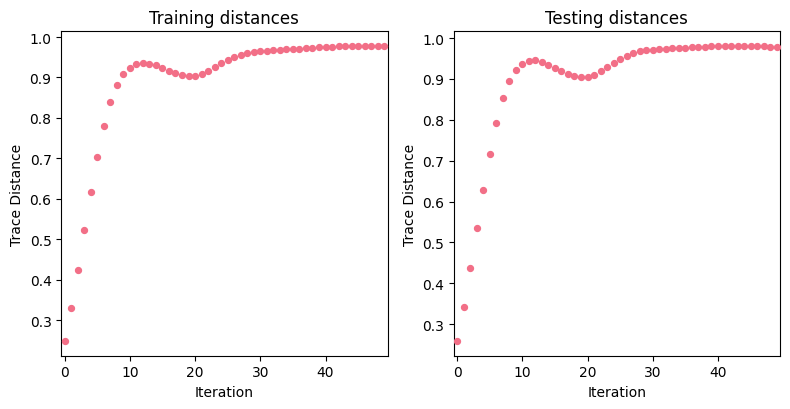

<Figure size 640x480 with 0 Axes>

In [9]:
plot_trace_distance(train_distances,test_distances,show=True)

### 6.2. Loss plot

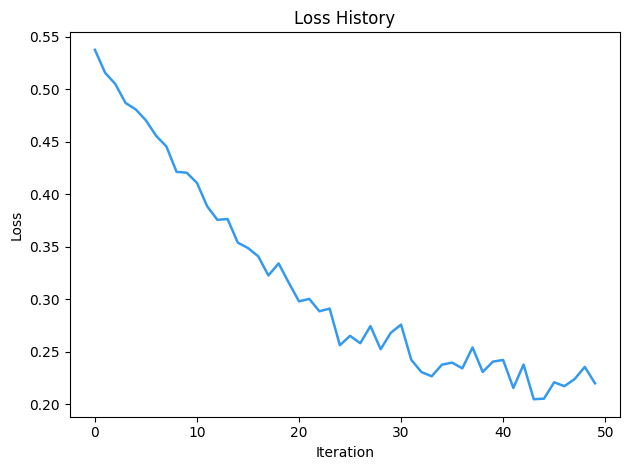

<Figure size 640x480 with 0 Axes>

In [10]:
quick_loss_plot(losses_classifier,show=True)

### 6.3. Accuracy plot

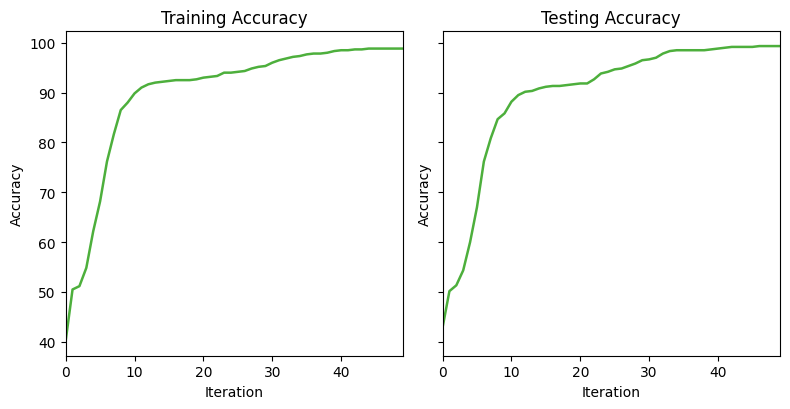

<Figure size 640x480 with 0 Axes>

In [11]:
plot_accuracies(train_accs,test_accs,show=True)

The same pipeline is used for the gate-based versions of this model (a few different technical details can be found in the docstrings of the objects). To reproduce the figure of the experiments, follow the steps in section 5 of the [ReadMe](README.md).